In [30]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
from random import sample
import matplotlib.pyplot as plt
import os
import cv2
from keras import layers
from keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.legacy import Adam
from proglearn.deciders import SimpleArgmaxAverage
from proglearn.progressive_learner import ProgressiveLearner
from proglearn.transformers import (
    NeuralClassificationTransformer,
    TreeClassificationTransformer,
)
from proglearn.voters import TreeClassificationVoter, KNNClassificationVoter
from sklearn.model_selection import train_test_split
from keras.backend import clear_session 
import pandas as pd
import pickle

In [4]:
total_scene = 11
total_class = 50

X = np.array(np.load('/Users/jayantadey/Downloads/core50_imgs.npz')['x'])
y = []

pkl_file = open('/Users/jayantadey/Downloads/paths.pkl', 'rb') 
paths = pickle.load(pkl_file)

for path in paths:
    splits = path.split('/')
    label = (int(splits[0][1:])-1)*50 + int(splits[1][1:]) - 1
    y.append(label)

y = np.array(y)
categories, class_counts = np.unique(y, return_counts=True)

Label  500


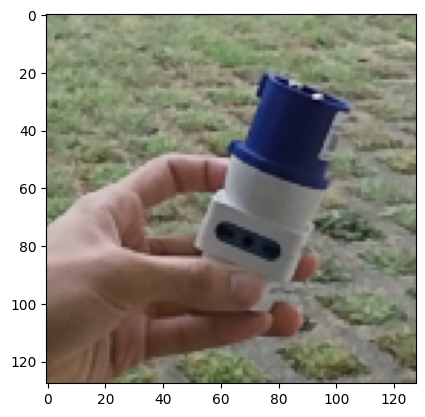

In [5]:
plt.imshow(X[0])
print('Label ',y[0])

In [14]:
CATEGORIES = list(range(11*50))
SAMPLE_PER_CLASS = 100
NUM_CLASS_PER_TASK = 5
IMG_SIZE = 128

In [15]:
def get_data(task=0):
    train_X = []
    train_y = []
    test_X = []
    test_y = []
    
    categories_to_consider = range(task*NUM_CLASS_PER_TASK,(task+1)*NUM_CLASS_PER_TASK)
    for category in categories_to_consider:
        idx = np.where(y==category)[0]
        total_images = len(idx)
        
        train_indx = sample(range(total_images), SAMPLE_PER_CLASS)
        test_indx = np.delete(range(total_images), train_indx)
        for ii in train_indx:
            train_X.append(
                X[idx[ii]]
            )
            train_y.append(
                y[idx[ii]]
            )
        for ii in test_indx:
            test_X.append(
                X[idx[ii]]
            )
            test_y.append(
                y[idx[ii]]
            )

    train_X = np.array(train_X)#.reshape(-1,IMG_SIZE,IMG_SIZE,3)
    train_y = np.array(train_y)
    test_X = np.array(test_X)#.reshape(-1,IMG_SIZE,IMG_SIZE,3)
    test_y = np.array(test_y)
    
    return train_X, train_y, test_X, test_y

In [18]:
def experiment(rep=1, budget=40):
    num_tasks = 110
    tasks = []
    base_tasks = []
    accuracies_across_tasks = []
    singletask_accuracy = []
    df_multitask = pd.DataFrame()
    df_singletask = pd.DataFrame()
    transformers_to_consider = []
    

    clear_session()  # clear GPU memory before each run, to avoid OOM error

    default_transformer_class = NeuralClassificationTransformer

    network = keras.Sequential()
    network.add(
        layers.Conv2D(
            filters=16,
            kernel_size=(3, 3),
            activation="relu",
            input_shape=(IMG_SIZE,IMG_SIZE,3),
        )
    )
    network.add(layers.BatchNormalization())
    network.add(
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            strides=2,
            padding="same",
            activation="relu",
        )
    )
    network.add(layers.BatchNormalization())
    network.add(
        layers.Conv2D(
            filters=64,
            kernel_size=(3, 3),
            strides=2,
            padding="same",
            activation="relu",
        )
    )
    network.add(layers.BatchNormalization())
    network.add(
        layers.Conv2D(
            filters=128,
            kernel_size=(3, 3),
            strides=2,
            padding="same",
            activation="relu",
        )
    )
    network.add(layers.BatchNormalization())
    network.add(
        layers.Conv2D(
            filters=254,
            kernel_size=(3, 3),
            strides=2,
            padding="same",
            activation="relu",
        )
    )

    network.add(layers.Flatten())
    network.add(layers.BatchNormalization())
    network.add(layers.Dense(2000, activation="relu"))
    network.add(layers.BatchNormalization())
    network.add(layers.Dense(2000, activation="relu"))
    network.add(layers.BatchNormalization())
    network.add(layers.Dense(units=NUM_CLASS_PER_TASK, activation="softmax"))  # units=10

    default_transformer_kwargs = {
        "network": network,
        "euclidean_layer_idx": -2,
        "loss": "categorical_crossentropy",
        "optimizer": Adam(3e-4),
        "fit_kwargs": {
            "epochs": 100,
            "callbacks": [EarlyStopping(patience=5, monitor="val_loss")],
            "verbose": False,
            "validation_split": 0.33,
            "batch_size": 32,
        },
    }
    default_voter_class = KNNClassificationVoter
    default_voter_kwargs = {"k": int(np.log2(NUM_CLASS_PER_TASK*SAMPLE_PER_CLASS))}
    default_decider_class = SimpleArgmaxAverage



    progressive_learner = ProgressiveLearner(
        default_transformer_class=default_transformer_class,
        default_transformer_kwargs=default_transformer_kwargs,
        default_voter_class=default_voter_class,
        default_voter_kwargs=default_voter_kwargs,
        default_decider_class=default_decider_class,
    )
    
    test_x_task = []
    test_y_task = []
    for task in range(num_tasks):
        print("doing task ", task)

        single_learner = ProgressiveLearner(
            default_transformer_class=default_transformer_class,
            default_transformer_kwargs=default_transformer_kwargs,
            default_voter_class=default_voter_class,
            default_voter_kwargs=default_voter_kwargs,
            default_decider_class=default_decider_class,
        )
        
        train_x, train_y, test_x, test_y = get_data(task)

        
        test_x_task.append(
            test_x
        )
        test_y_task.append(
            test_y
        )

        single_learner.add_task(
                    X=train_x,
                    y=train_y,
                    task_id=task,
                    num_transformers=1,
                    transformer_voter_decider_split=[0.67, 0.33, 0],
                    decider_kwargs={"classes": np.unique(train_y)},
                )
        
        if task < budget:    
            transformers_to_consider.append(task)

            progressive_learner.add_task(
                    X=train_x,
                    y=train_y,
                    task_id=task,
                    num_transformers=1,
                    transformer_voter_decider_split=[0.67, 0.33, 0],
                    decider_kwargs={"classes": np.unique(train_y)},
                )
        else:
            progressive_learner.add_task(
                    X=train_x,
                    y=train_y,
                    task_id=task,
                    num_transformers=0,
                    transformer_voter_decider_split=[0.67, 0.33, 0],
                    decider_kwargs={"classes": np.unique(train_y)},
                )
            progressive_learner.task_id_to_X = {}
            progressive_learner.task_id_to_y = {}
            

        if task == 0:
            singletask_prediction = progressive_learner.predict(
                X=test_x, transformer_ids=[task], task_id=task
            )
        else:
            singletask_prediction = single_learner.predict(
                X=test_x, transformer_ids=[task], task_id=task
            )

        
        singletask_accuracy.append(
            np.mean(singletask_prediction==test_y)
        )
        print('accuracy ',np.mean(singletask_prediction==test_y))
        for ii in range(task+1):
            multitask_prediction = progressive_learner.predict(
                X=test_x_task[ii], transformer_ids=transformers_to_consider, task_id=ii
            )
            acc = np.mean(multitask_prediction==test_y_task[ii])
            print('task ',ii,' accuracy ', acc)
            base_tasks.append(task+1)
            tasks.append(ii+1)
            accuracies_across_tasks.append(
                np.mean(multitask_prediction == test_y_task[ii])
            )

    df_multitask['task'] = tasks
    df_multitask['base_task'] = base_tasks
    df_multitask['accuracy'] = accuracies_across_tasks

    df_singletask['task'] = list(range(1,num_tasks+1))
    df_singletask['accuracy'] = singletask_accuracy

    summary = (df_multitask, df_singletask)

    with open('results/'+model+'_'+str(rep)+'fixed_' + str(budget)+'.pickle', 'wb') as f:
        pickle.dump(summary, f)

In [21]:
reps = 20

for jj in range(reps):
        experiment(rep=jj, budget=5)

doing task  0


2025-02-13 14:59:03.146047: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-02-13 14:59:04.706256: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


4/6 [===================>..........] - ETA: 0s

2025-02-13 14:59:11.004297: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


6/6 [==============================] - 0s 28ms/step


...

 1/16 [>.............................] - ETA: 3s

2025-02-13 15:00:42.792303: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


32/32 [==============================] - 0s 9ms/step
accuracy  0.7267267267267268
32/32 [==============================] - 0s 10ms/step
task  0  accuracy  0.8734939759036144
32/32 [==============================] - 0s 5ms/step
task  1  accuracy  0.8916750250752257
32/32 [==============================] - 0s 8ms/step
task  2  accuracy  0.980980980980981
doing task  3


2025-02-13 15:00:49.120545: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-02-13 15:00:51.299347: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


KeyboardInterrupt: 

In [34]:
with open('results/sillyN_0'+'fixed_20.pickle', 'rb') as f:
    res, res2 = pickle.load(f)

In [37]:
res.head()

,task,base_task,accuracy
0,1,1,0.611446
1,1,2,0.665663
2,2,2,0.744233
3,1,3,0.781124
4,2,3,0.788365


In [38]:
res2.head()

,task,accuracy
0,1,0.611446
1,2,0.743230
2,3,0.812813
3,4,0.730731
4,5,0.977000
